## 1. Import Libraries

In [ ]:
import pandas as pd
import scipy.sparse as sp
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 2. Load Dataset

In [20]:
dataset = pd.read_csv("ai_job_market_trend.csv")

In [21]:
dataset.head()

,job_id,job_role,experience_level,years_of_experience,education_level,skills,tools_and_technologies,certifications,industry,employment_type,location,company_size,annual_salary_usd,remote_friendly
0,1,AI Researcher,Entry,1,Bachelor's,"Deep Learning, SQL, Experimentation, Algorithm...",JAX,NaN,Robotics,Full-time,"Austin, TX",Large,90697,Hybrid
1,2,AI Researcher,Mid,3,Master's,"Communication, Scikit-learn, Publications, Pyt...","JAX, SLURM, Weights & Biases",NeurIPS Paper,Tech,Full-time,"Chicago, IL",Large,142298,Yes
2,3,Quant Researcher,Mid,6,Master's,"R, Derivatives Pricing, Mathematics, Risk Mode...","KDB+, R, Python",CFA Level I,Banking,Remote,"London, UK",Large,139116,Yes
3,4,AI Researcher,Mid,2,PhD,"Publications, LaTeX, Python, Data Analysis, Al...","Overleaf, PyTorch, JAX",NaN,Finance,Full-time,"Atlanta, GA",Startup,144867,No
4,5,ML Engineer,Mid,5,Bachelor's,"SQL, Python, Visualization, PyTorch, Cloud (AW...","TensorFlow, Docker, PyTorch",GCP Professional ML,Finance,Full-time,"Dublin, Ireland",Mid-size,158956,Hybrid


In [22]:
print('Shape:', dataset.shape)
print()

Shape: (5000, 14)



In [23]:
print(dataset.isnull().sum())

job_id                       0
job_role                     0
experience_level             0
years_of_experience          0
education_level              0
skills                       0
tools_and_technologies       0
certifications            1476
industry                     0
employment_type              0
location                     0
company_size                 0
annual_salary_usd            0
remote_friendly              0
dtype: int64


In [24]:
dataset['job_role'].value_counts()

job_role
Data Scientist              668
ML Engineer                 628
Data Analyst                604
NLP Engineer                568
AI Product Manager          539
Computer Vision Engineer    524
AI Researcher               509
Data Engineer               507
Quant Researcher            453
Name: count, dtype: int64

## 3. Data Preprocessing

In [25]:
# Data Imputation
dataset['certifications'] = dataset['certifications'].fillna('none')

# Combine skill-related text columns into one feature
dataset['skills_combined'] = (
    dataset['skills'].fillna('') + ' ' +
    dataset['tools_and_technologies'].fillna('') + ' ' +
    dataset['certifications'].fillna('')
)

In [26]:
print(dataset['skills_combined'].head())

0    Deep Learning, SQL, Experimentation, Algorithm...
1    Communication, Scikit-learn, Publications, Pyt...
2    R, Derivatives Pricing, Mathematics, Risk Mode...
3    Publications, LaTeX, Python, Data Analysis, Al...
4    SQL, Python, Visualization, PyTorch, Cloud (AW...
Name: skills_combined, dtype: object


In [27]:
# Encoding the data
categorical_cols = ['experience_level', 'education_level', 'industry',
                    'employment_type', 'company_size', 'remote_friendly']
numeric_cols     = ['years_of_experience', 'annual_salary_usd']

dataset_struct = dataset[categorical_cols + numeric_cols].copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    dataset_struct[col] = le.fit_transform(dataset_struct[col])
    label_encoders[col] = le

In [28]:
print(dataset_struct.head())

   experience_level  education_level  industry  employment_type  company_size  \
0                 0                0        17                1             0   
1                 1                1        19                1             0   
2                 1                1         2                4             0   
3                 1                2         7                1             2   
4                 1                0         7                1             1   

   remote_friendly  years_of_experience  annual_salary_usd  
0                0                    1              90697  
1                2                    3             142298  
2                2                    6             139116  
3                1                    2             144867  
4                0                    5             158956  


In [29]:
# Encode target label
target_le = LabelEncoder()
y = target_le.fit_transform(dataset['job_role'])
print('Classes:', list(target_le.classes_))

Classes: ['AI Product Manager', 'AI Researcher', 'Computer Vision Engineer', 'Data Analyst', 'Data Engineer', 'Data Scientist', 'ML Engineer', 'NLP Engineer', 'Quant Researcher']


In [30]:
print(y)

[1 1 8 ... 8 3 8]


In [ ]:
# Vectorise skill text 
count_vectorizer = CountVectorizer(max_features=18, ngram_range=(1, 1))
skills_matrix = count_vectorizer.fit_transform(dataset['skills_combined'])
print('Skills vocabulary size:', len(count_vectorizer.vocabulary_))

Skills vocabulary size: 18


In [32]:
# Combine structural features + skill text features
X = sp.hstack([sp.csr_matrix(dataset_struct.values), skills_matrix])
print('Feature matrix shape:', X.shape)

Feature matrix shape: (5000, 26)


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape, '  Test:', X_test.shape)

Train: (4000, 26)   Test: (1000, 26)


## 4. Model Training & Evaluation

In [ ]:
# Random Forest 
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf       = rf_model.predict(X_test)
rf_train_acc = accuracy_score(y_train, y_pred_rf_train)
rf_test_acc  = accuracy_score(y_test,  y_pred_rf)
print(f"Random Forest  |  Train Accuracy: {rf_train_acc:.4f}  |  Test Accuracy: {rf_test_acc:.4f}")

Random Forest  |  Train Accuracy: 0.8377  |  Test Accuracy: 0.7710


In [ ]:
# Logistic Regression (baseline)
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr       = lr_model.predict(X_test)
lr_train_acc = accuracy_score(y_train, y_pred_lr_train)
lr_test_acc  = accuracy_score(y_test,  y_pred_lr)
print(f"Logistic Regression  |  Train Accuracy: {lr_train_acc:.4f}  |  Test Accuracy: {lr_test_acc:.4f}")

Logistic Regression  |  Train Accuracy: 0.5995  |  Test Accuracy: 0.5660


c:\Users\sasan\OneDrive\Desktop\Very Importants\ML Project Evaluation\RoleCast-AI\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Accuracy Summary Table
results = pd.DataFrame({
    'Algorithm':       ['Random Forest', 'Logistic Regression'],
    'Train Accuracy':  [rf_train_acc,   lr_train_acc],
    'Test Accuracy':   [rf_test_acc,    lr_test_acc],
    'Overfit Gap':     [rf_train_acc - rf_test_acc, lr_train_acc - lr_test_acc],
})
results[['Train Accuracy','Test Accuracy','Overfit Gap']] = results[['Train Accuracy','Test Accuracy','Overfit Gap']].applymap(lambda x: f'{x:.4f}')
print(results.to_string(index=False))

          Algorithm Train Accuracy Test Accuracy Overfit Gap
      Random Forest         0.8377        0.7710      0.0667
Logistic Regression         0.5995        0.5660      0.0335


C:\Users\sasan\AppData\Local\Temp\ipykernel_40784\796303912.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results[['Train Accuracy','Test Accuracy','Overfit Gap']] = results[['Train Accuracy','Test Accuracy','Overfit Gap']].applymap(lambda x: f'{x:.4f}')


In [ ]:
# 5-Fold Cross-Validation (Random Forest)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='accuracy')
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold:    {[round(s,4) for s in cv_scores]}")

CV Accuracy: 0.7652 ± 0.0115
Per-fold:    [np.float64(0.7738), np.float64(0.775), np.float64(0.7725), np.float64(0.745), np.float64(0.76)]


## 5. Detailed Classification Report

In [38]:
print("=" * 60)
print("Classification Report — Random Forest")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=target_le.classes_))

Classification Report — Random Forest
                          precision    recall  f1-score   support

      AI Product Manager       0.68      0.74      0.71       108
           AI Researcher       0.78      0.61      0.69       102
Computer Vision Engineer       0.74      0.46      0.56       105
            Data Analyst       0.92      0.93      0.92       121
           Data Engineer       0.83      0.77      0.80       101
          Data Scientist       0.89      0.91      0.90       133
             ML Engineer       0.83      0.80      0.82       126
            NLP Engineer       0.57      0.76      0.65       113
        Quant Researcher       0.73      0.91      0.81        91

                accuracy                           0.77      1000
               macro avg       0.77      0.77      0.76      1000
            weighted avg       0.78      0.77      0.77      1000



## 6. Confusion Matrix

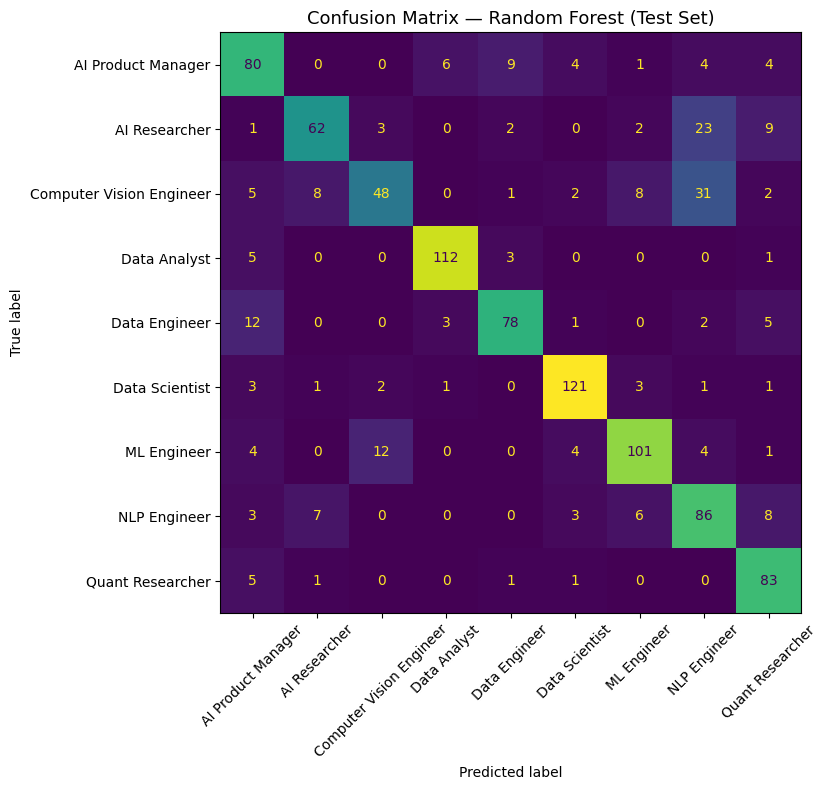

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=target_le.classes_,
    ax=ax,
    colorbar=False,
    xticks_rotation=45
)
ax.set_title("Confusion Matrix — Random Forest (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 7. Save Model & Artefacts

In [40]:
with open('rolecast_rf_model.pkl', 'wb') as f:
    pickle.dump({
        'model': rf_model,
        'count_vectorizer': count_vectorizer,
        'label_encoders': label_encoders,
        'target_le': target_le,
        'categorical_cols': categorical_cols,
        'numeric_cols': numeric_cols,
    }, f)
print('Model saved to rolecast_rf_model.pkl')

Model saved to rolecast_rf_model.pkl
